## Imports and Data Prep

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from letterboxd_utils import clean_diary_data, remove_duplicate_movies, linear_regression_numpy, predict_linear_regression, accuracy_within_half_star, get_tmdb_data, fetch_imdb_ratings
import requests
from bs4 import BeautifulSoup
import re
import unicodedata

/var/folders/sh/9y2x7hyx76bghklsygtm6m000000gn/T/ipykernel_49311/4267691261.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
def get_user_diary(username):
    """Creates a DataFrame of a user's Letterboxd diary given their username

    Args: 
        username (string): Letterboxd username

    Returns:
        df (DataFrame): DataFrame containing the information in a user's diary (movies, ratings, etc.)
    """

    # Finding the max page number
    url = f'https://letterboxd.com/{username}/films/diary/'
    html = requests.get(url).text
    soup = BeautifulSoup(html, 'html.parser')
    pagination = soup.find('div', class_='pagination')
    if pagination:
        max_page = int(pagination.find_all('li', class_='paginate-page')[-1].text) 
    else:
        max_page = 1

    all_data = [] 
    current_month = None 

    film_slug_list = []

    for i in range(1, max_page + 1):
        url = f'https://letterboxd.com/{username}/films/diary/page/{i}'
        html = requests.get(url).text
        soup = BeautifulSoup(html, 'html.parser')

        month_watched = soup.find_all(class_='td-calendar')
        day_watched = soup.find_all(class_='td-day diary-day center')
        films = soup.find_all('h3', class_='headline-3 prettify')
        released_dates = soup.find_all(class_='td-released center')
        ratings = soup.find_all('span', class_='rating')

        for j in range(len(films)): 
            if month_watched:
                current_month = month_watched[j].get_text(strip=True) if month_watched[j].get_text(strip=True) else current_month
            
            # getting film title for genre lookup
            film_title = films[j].get_text(strip=True)
            film_link = films[j].find('a')['href']  # Get the href attribute
            # Extract the slug from the href (format is "/username/film/film-slug/")
            film_slug = film_link.split('/')[3]  # Get the fourth element after splitting
                
            film_slug_list.append(film_slug)
            
            # fetching genres using the name of the film
            genre_url = f'https://letterboxd.com/film/{film_slug}/genres/'
            genre_html = requests.get(genre_url).text
            genre_soup = BeautifulSoup(genre_html, 'html.parser')
            genres = genre_soup.find('div', class_='text-sluglist capitalize')
            
            if genres:
                genre_list = [genre.text for genre in genres.find_all('a', class_='text-slug')]
                genres_str = ', '.join(genre_list) # joining the genres with commas
                
            else:
                genres_str = None
            
            data = {
                'Month': current_month,
                'Day': day_watched[j].get_text(strip=True) if j < len(day_watched) else None,
                'Film': film_title,
                'Released': released_dates[j].get_text(strip=True) if j < len(released_dates) else None,
                'Ratings': ratings[j].get_text(strip=True) if j < len(ratings) else None,
                'Genres': genres_str 
            }
            all_data.append(data)
            
    df = pd.DataFrame(all_data)
    return df, film_slug_list

In [3]:
username = 'kmgrimes'
df, film_slug_list = get_user_diary(username)
df = clean_diary_data(df)
df['Released'] = pd.to_numeric(df['Released'])
df['Day'] = pd.to_numeric(df['Day'])
df = remove_duplicate_movies(df)

unique_film_list = list(set(film_slug_list))
print(unique_film_list)
print(len(unique_film_list))


['the-meg', 'monsters-vs-aliens', 'the-hunger-games-catching-fire', 'five-nights-at-freddys', 'the-hunger-games-mockingjay-part-2', 'the-handmaiden', 'piece-by-piece-2024', 'angel-falls-christmas', 'island-of-lost-souls', 'the-greatest-night-in-pop', 'zootopia', 'ice-princess', 'the-hunger-games-the-ballad-of-songbirds-snakes', 'cars', 'but-im-a-cheerleader', 'the-maltese-falcon-1941', 'inside-out-2-2024', 'casablanca', 'best-in-show', 'everybody-wants-some', 'zatoichis-cane-sword', 'bottoms', 'the-way-way-back', 'moonlight-2016', 'poor-things-2023', 'labyrinth', 'the-little-hours', 'julie-julia', 'kinds-of-kindness', 'night-flight-2014', 'the-little-mermaid', 'wonka', 'asteroid-city', 'teenage-mutant-ninja-turtles-mutant-mayhem', 'bodies-bodies-bodies', 'moulin-rouge-2001', 'la-la-land', 'the-matrix', 'it-chapter-two', 'brokeback-mountain', 'falling-for-christmas', 'parasite-2019', 'penguins-of-madagascar-2014', 'anatomy-of-a-fall', 'eighth-grade', 'mamma-mia', 'clue', 'the-holdovers'

In [4]:
df.head()

,Month,Day,Film,Released,Ratings,Genres,Year
0,11,25,Gladiator II,2024,3.5,"History, Action, Adventure",2024
1,11,21,Wicked,2024,4.0,"Romance, Drama, Fantasy",2024
2,11,20,The Hangover,2009,4.0,Comedy,2024
3,11,18,Don't Move,2024,2.0,"Horror, Thriller",2024
4,10,23,Piece By Piece,2024,3.0,"Documentary, Animation, Music",2024


In [5]:
print(df)

     Month  Day                   Film  Released  Ratings  \
0       11   25           Gladiator II      2024      3.5   
1       11   21                 Wicked      2024      4.0   
2       11   20           The Hangover      2009      4.0   
3       11   18             Don't Move      2024      2.0   
4       10   23         Piece By Piece      2024      3.0   
..     ...  ...                    ...       ...      ...   
177      2   12  But I'm a Cheerleader      1999      4.0   
178      2    6                Maurice      1987      3.0   
179     10   30                  Ponyo      2008      5.0   
180     10   26            Open Season      2006      3.0   
181      1   19         It Chapter Two      2019      5.0   

                                   Genres  Year  
0              History, Action, Adventure  2024  
1                 Romance, Drama, Fantasy  2024  
2                                  Comedy  2024  
3                        Horror, Thriller  2024  
4           Docum

## One-Hot Genres Vector With Release Date to Predict Rating

In [6]:
# Handle missing genres and create a list of unique genres
df['Genres'] = df['Genres'].fillna('None')

all_genres = []
for genres in df['Genres']:
    for genre in genres.split(', '):
        if genre not in all_genres:
            all_genres.append(genre)
unique_genres = sorted(list(set(all_genres)))
num_genres = len(unique_genres)
print(all_genres)

['History', 'Action', 'Adventure', 'Romance', 'Drama', 'Fantasy', 'Comedy', 'Horror', 'Thriller', 'Documentary', 'Animation', 'Music', 'Family', 'Mystery', 'Science Fiction', 'Crime', 'TV Movie', 'Western']


In [7]:
# transferring to numpy arrays instead of pandas dfs
release_year = df['Released'].values.reshape(-1, 1)  # to a column vector
genre_matrix = np.zeros((len(df), num_genres)) # intialize a matrix of zeros

In [8]:
# One-Hot Encoding for Genres (Feature Matrix)
for i, genres in enumerate(df['Genres']):
    for genre in genres.split(', '):
        j = unique_genres.index(genre)
        genre_matrix[i, j] = 1

In [9]:
# Combine Release Year and Genre Matrix
X = np.concatenate((release_year, genre_matrix), axis=1) #concatenate the release year and the genres together
y = df['Ratings'].values

In [10]:
print("Features Matrix (X) shape:", X.shape)
print("Target Variable (y) shape:", y.shape)
print("\nFeatures (X):")
print(X[2:5])
print("\nTarget Variable (y):")
print(y)

Features Matrix (X) shape: (182, 19)
Target Variable (y) shape: (182,)

Features (X):
[[2.009e+03 0.000e+00 0.000e+00 0.000e+00 1.000e+00 0.000e+00 0.000e+00
  0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
  0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00]
 [2.024e+03 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
  0.000e+00 0.000e+00 0.000e+00 0.000e+00 1.000e+00 0.000e+00 0.000e+00
  0.000e+00 0.000e+00 0.000e+00 1.000e+00 0.000e+00]
 [2.024e+03 0.000e+00 0.000e+00 1.000e+00 0.000e+00 0.000e+00 1.000e+00
  0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 1.000e+00 0.000e+00
  0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00]]

Target Variable (y):
[3.5 4.  4.  2.  3.  4.  4.5 3.  3.  4.  0.  3.  5.  1.5 3.5 4.  5.  2.5
 3.  4.  2.  4.  1.5 4.  5.  3.  3.5 3.  3.5 4.  3.  2.5 4.  2.5 4.5 3.
 2.5 4.  3.5 4.5 2.5 5.  4.  3.5 3.5 3.  2.  3.5 4.  0.  4.5 4.5 4.  4.
 3.  3.5 4.  4.5 4.  4.5 4.  4.  4.5 3.5 1.5 5.  2.5 5.  3.5 1.5 3.5 2.5
 3.5 4.  4

#### Splitting the data 60-20-20, train-validation-test

In [11]:
indices = np.arange(X.shape[0]) #create an array of numbers representing the index of the row
np.random.seed(42) #setting a random seed for reproducibility
np.random.shuffle(indices) #shuffles the indices in place

In [12]:
train_cutoff = int(0.6 * len(indices)) #gets the first 60% of the indices
val_cutoff = int(0.8 * len(indices)) #gets the next 20% of the indices after the training cutoff

train_indices = indices[:train_cutoff] #indices for the training set
val_indices = indices[train_cutoff:val_cutoff] #indices for the validation set
test_indices = indices[val_cutoff:] #indices for the test set

In [13]:
X_train, y_train = X[train_indices], y[train_indices] #training set
X_val, y_val = X[val_indices], y[val_indices] #validation set
X_test, y_test = X[test_indices], y[test_indices] #test set

### linear regression defined in the utils file, training portion

In [14]:
# training
weights, intercept = linear_regression_numpy(X_train, y_train)

In [15]:
# predictions on validation and test sets
y_val_pred_np = predict_linear_regression(X_val, weights, intercept)
y_test_pred_np = predict_linear_regression(X_test, weights, intercept)

In [16]:
mse_val_np = mean_squared_error(y_val, y_val_pred_np)
r2_val_np = r2_score(y_val, y_val_pred_np)
mse_test_np = mean_squared_error(y_test, y_test_pred_np)
r2_test_np = r2_score(y_test, y_test_pred_np)

print(f"NumPy - Validation MSE: {mse_val_np:.2f}, R-squared: {r2_val_np:.2f}")
print(f"NumPy - Test MSE: {mse_test_np:.2f}, R-squared: {r2_test_np:.2f}")

NumPy - Validation MSE: 1.62, R-squared: -0.19
NumPy - Test MSE: 0.85, R-squared: -0.15


In [17]:
accuracy_val = accuracy_within_half_star(y_val, y_val_pred_np)
accuracy_test = accuracy_within_half_star(y_test, y_test_pred_np)
print(f"NumPy - Validation Accuracy (within 0.5 stars): {accuracy_val:.2f}")
print(f"NumPy - Test Accuracy (within 0.5 stars): {accuracy_test:.2f}")

NumPy - Validation Accuracy (within 0.5 stars): 0.28
NumPy - Test Accuracy (within 0.5 stars): 0.46


## Testing Assumptions

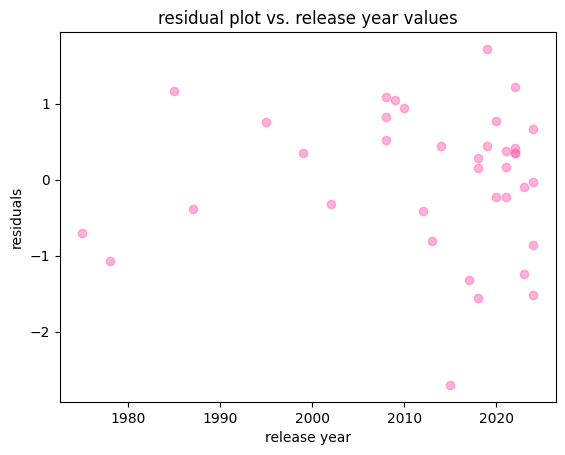

In [18]:
# independence assumption
resids =  y_test - y_test_pred_np
X_test_0 = X_test[:, 0]

plt.scatter(X_test_0, resids, alpha=0.5, color="hotpink")
plt.xlabel("release year")
plt.ylabel("residuals")
plt.title("residual plot vs. release year values")
plt.show()

This plot is close to being centered around zero, which is good. The variance though is cause for concern, it has unequal distribution. This raises issues with the independence assumption being met. 

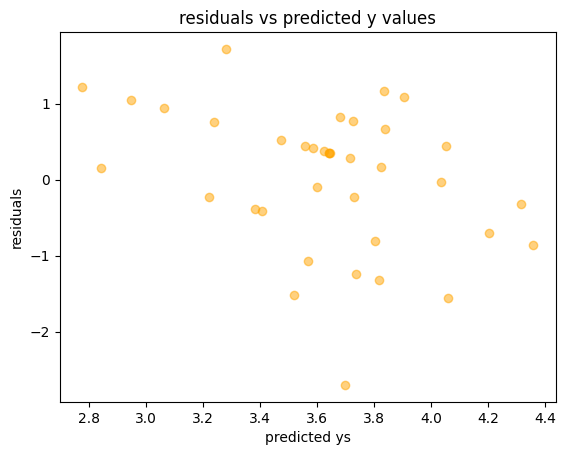

In [19]:
# constant variance
plt.scatter(y_test_pred_np, resids, alpha=.5, color="orange")
plt.xlabel('predicted ys')
plt.ylabel('residuals')
plt.title('residuals vs predicted y values')
plt.show()

This plot reveals two things of importance. First, this appears to be centered around zero which is good for meeting the constant variance assumption. The variance though, is not constant which is not good. Second, the outlier here reveals that our algorithm is not cutting off at the correct place, as the maximum rating should be 5.0. It is interesting that the model did not predict any scores of 2.5 or lower. 

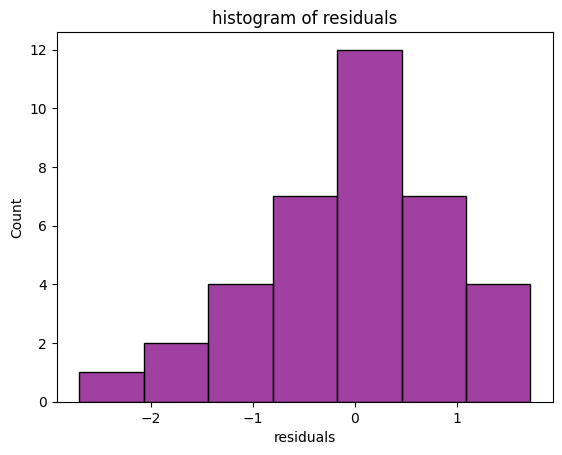

In [20]:
# histogram of residuals
sns.histplot(resids, kde=False, color="purple")
plt.xlabel("residuals")
plt.title("histogram of residuals")
plt.show()

The histogram does not follow the normal curve. This is not good, and indicates that the normality assumption is not met. 

Overall, our results are pretty bad as the baseline of random guessing with + or - 0.5 stars is 30% accuracy. The above plots indicate that there are significant issues with the data meeting the linear regression assumptions. Going forward we probably should try a more complex model with the limited data we have as basic linear regression isn't producing a great result here. Further, we aim in the next phase to implement an additional API that will allow us to scrape more movie features and build a more comprehensive dataset. 

Issues we have identified: 
- Limited features: Genre and release date are likely insufficient predictors of movie ratings. We wanted to test this out first with our preliminary model to see the mathematical proof that more features are necessary for a stronger model. The poor accuracy was predicted by our group, and now we have strong evidence to support additional feature finding. 

- Small dataset: Since the model runs on a specific user's watched and rated movies, it is limited by a small dataset. Here, we pull from a group member's Letterboxd which currently has 170 movies logged. After splitting this dataset into training sets, testing sets, and validation sets, we are left with kind of a small amount of movies to test the linear regression on. 

Next Steps 
- Feature finding and engineering: We will implement an additional API to gather features from the watched movies. Some features we aim to gather are IMDb ratings, budget, cast, director, and profit. We need a larger, more diverse dataset (Kyra, the group member with the letterboxd account, will keep watching and rating movies!). It would also be interesting to consider derived features (ex. a popularity score based on popular rating and profit). We also hope to try more complex machine learning models such as KNN which may provide better accuracy results. 

In [21]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
pd.set_option('display.max_colwidth', None)

import time

In [22]:
# Lin's proposal 
# get the top-250 movies data frm Flickfocus
url = 'https://flickfocus.com/movies/'
url_list = []
for movie in unique_film_list:
    url_list.append(url + movie)

response_list = []
for url in url_list:
    response_list.append(requests.get(url))

soup_list = []
for response in response_list:
    soup = BeautifulSoup(response.text, "html.parser")
    soup_list.append(soup)


print(soup_list)


[<!DOCTYPE html>
<html lang="en-US"><head><title>Just a moment...</title><meta content="text/html; charset=utf-8" http-equiv="Content-Type"/><meta content="IE=Edge" http-equiv="X-UA-Compatible"/><meta content="noindex,nofollow" name="robots"/><meta content="width=device-width,initial-scale=1" name="viewport"/><style>*{box-sizing:border-box;margin:0;padding:0}html{line-height:1.15;-webkit-text-size-adjust:100%;color:#313131;font-family:system-ui,-apple-system,BlinkMacSystemFont,Segoe UI,Roboto,Helvetica Neue,Arial,Noto Sans,sans-serif,Apple Color Emoji,Segoe UI Emoji,Segoe UI Symbol,Noto Color Emoji}body{display:flex;flex-direction:column;height:100vh;min-height:100vh}.main-content{margin:8rem auto;max-width:60rem;padding-left:1.5rem}@media (width <= 720px){.main-content{margin-top:4rem}}.h2{font-size:1.5rem;font-weight:500;line-height:2.25rem}@media (width <= 720px){.h2{font-size:1.25rem;line-height:1.5rem}}#challenge-error-text{background-image:url();background-repeat:no-repeat;backgr

In [23]:
print(url_list)
len(url_list)

print(response_list)
error_list = []
for response in response_list:
    if (response.status_code == 404):
        error_list.append(response)

print(error_list)

['https://flickfocus.com/movies/the-meg', 'https://flickfocus.com/movies/monsters-vs-aliens', 'https://flickfocus.com/movies/the-hunger-games-catching-fire', 'https://flickfocus.com/movies/five-nights-at-freddys', 'https://flickfocus.com/movies/the-hunger-games-mockingjay-part-2', 'https://flickfocus.com/movies/the-handmaiden', 'https://flickfocus.com/movies/piece-by-piece-2024', 'https://flickfocus.com/movies/angel-falls-christmas', 'https://flickfocus.com/movies/island-of-lost-souls', 'https://flickfocus.com/movies/the-greatest-night-in-pop', 'https://flickfocus.com/movies/zootopia', 'https://flickfocus.com/movies/ice-princess', 'https://flickfocus.com/movies/the-hunger-games-the-ballad-of-songbirds-snakes', 'https://flickfocus.com/movies/cars', 'https://flickfocus.com/movies/but-im-a-cheerleader', 'https://flickfocus.com/movies/the-maltese-falcon-1941', 'https://flickfocus.com/movies/inside-out-2-2024', 'https://flickfocus.com/movies/casablanca', 'https://flickfocus.com/movies/best-

In [24]:
movies_df = pd.DataFrame({
    'Film': df['Film'],
    'Released': df['Released']
})

tmdb_data = get_tmdb_data(movies_df, '4891dd286064835e1f235e7ab4f52baa')


Fetching TMDB data:   0%|          | 0/182 [00:00<?, ?it/s]

Fetching TMDB data: 100%|██████████| 182/182 [02:03<00:00,  1.47it/s]


In [25]:
# add user ratings
tmdb_data['User Rating'] = df['Ratings']

# Handle both budget and revenue zeros (using numpy's NaN instead of None for dfs)
import numpy as np
tmdb_data['Budget'] = tmdb_data['Budget'].replace(0, np.nan)
tmdb_data['Revenue'] = tmdb_data['Revenue'].replace(0, np.nan)

# Add IMDb ratings
imdb_ratings = fetch_imdb_ratings(tmdb_data)
tmdb_data['IMDb Rating'] = imdb_ratings

# profit and ROI
tmdb_data['Profit'] = tmdb_data['Revenue'] - tmdb_data['Budget']

# For ROI, we'll only calculate where we have both budget and revenue
tmdb_data['ROI'] = np.where(
    tmdb_data['Budget'] > 0,
    tmdb_data['Profit'] / tmdb_data['Budget'],
    np.nan
)

print("Missing values per column:")
print(tmdb_data.isnull().sum())

Missing values per column:
Original Title      0
TMDB ID             0
IMDb ID             0
Budget             32
Revenue            28
TMDB Rating         0
TMDB Vote Count     0
Popularity          0
Genres              0
Adult               0
User Rating         0
IMDb Rating         0
Profit             35
ROI                35
dtype: int64


In [26]:
tmdb_data.head

<bound method NDFrame.head of             Original Title  TMDB ID     IMDb ID       Budget      Revenue  \
0             Gladiator II   558449   tt9218128  310000000.0  329092895.0   
1                   Wicked   402431   tt1262426  150000000.0  382799270.0   
2             The Hangover    18785   tt1119646   35000000.0  469310836.0   
3               Don't Move  1063877  tt24807110          NaN          NaN   
4           Piece By Piece  1236419  tt31064841   16000000.0   10291872.0   
..                     ...      ...         ...          ...          ...   
177  But I'm a Cheerleader    20770   tt0179116    1200000.0    2600000.0   
178                Maurice    26371   tt0093512    2600000.0    2438304.0   
179                  Ponyo    12429   tt0876563   34000000.0  202404009.0   
180            Open Season     7484   tt0400717   85000000.0  197300000.0   
181         It Chapter Two   474350   tt7349950   79000000.0  473123154.0   

     TMDB Rating  TMDB Vote Count  Popularity